# ARIA v2.0: Integrated Impact Auditor (Terrain-Enhanced)

## Captain's Log: Week 4 Mission
**Objective**: Upgrade Week 3 ARIA system with terrain intelligence using MOI 20m DEM
**Enhancement**: From river-only risk to composite risk (distance + elevation + slope)
**Target**: Hualien County (recommended) - mountainous terrain requires terrain analysis

### Key Upgrades from Week 3:
- **v1.0**: River buffer distance only
- **v2.0**: River distance + elevation + slope composite risk
- **Data**: MOI 20m DEM integration
- **Analysis**: Zonal statistics for terrain metrics

---

## Infrastructure Setup & Data Sources

### Vector Data (Week 3 Continuity)
- **Water Resources Agency**: River polygons (Shapefile)
- **Fire Agency**: Emergency shelters (CSV from data.gov.tw/dataset/73242)
- **National Land Surveying**: Township boundaries

### Raster Data (New - Week 4)
- **MOI 20m DEM**: https://data.gov.tw/dataset/176927
- **Format**: GeoTIFF (.tif), 20m × 20m resolution
- **CRS**: EPSG:3826 (TWD97 / TM2)
- **Size**: Full Taiwan DEM > 500MB → **Must clip before analysis**

In [1]:
# Cell 1: Environment Setup and Imports
import geopandas as gpd
import rioxarray as rxr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterstats
from urllib.parse import quote
import os
from dotenv import load_dotenv
from shapely.geometry import Point
import json
from datetime import datetime

print("✅ ARIA v2.0 Environment Setup Complete")
print(f"GeoPandas: {gpd.__version__}")
print(f"rioxarray: {rxr.__version__}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ ARIA v2.0 Environment Setup Complete
GeoPandas: 1.1.3
rioxarray: 0.19.0
Timestamp: 2026-03-18 14:58:05


## Step 1: Load Environment Variables and Configuration

**Captain's Log**: Loading mission parameters from environment configuration. Critical for reproducible analysis.

In [2]:
# Load environment variables
load_dotenv()

# Mission parameters from .env
SLOPE_THRESHOLD = float(os.getenv('SLOPE_THRESHOLD', 30))
ELEVATION_LOW = float(os.getenv('ELEVATION_LOW', 50))
BUFFER_HIGH = int(os.getenv('BUFFER_HIGH', 500))
BUFFER_MED = int(os.getenv('BUFFER_MED', 1000))
BUFFER_LOW = int(os.getenv('BUFFER_LOW', 2000))
TARGET_COUNTY = os.getenv('TARGET_COUNTY', '花蓮縣')

print(f"🎯 ARIA v2.0 Mission Parameters:")
print(f"   Target County: {TARGET_COUNTY}")
print(f"   Slope Threshold: {SLOPE_THRESHOLD}°")
print(f"   Low Elevation Threshold: {ELEVATION_LOW}m")
print(f"   River Buffers: High={BUFFER_HIGH}m, Med={BUFFER_MED}m, Low={BUFFER_LOW}m")

# Create outputs directory
os.makedirs('outputs', exist_ok=True)
print(f"✅ Outputs directory ready")

🎯 ARIA v2.0 Mission Parameters:
   Target County: 花蓮縣
   Slope Threshold: 30.0°
   Low Elevation Threshold: 50.0m
   River Buffers: High=500m, Med=1000m, Low=2000m
✅ Outputs directory ready


## Step 2: Load Week 3 Vector Data (Continuity)

**Captain's Log**: Retrieving established Week 3 infrastructure. River and shelter data are foundation for terrain enhancement.

In [ ]:
# Load river data (Water Resources Agency)
WRA_URL = "https://gic.wra.gov.tw/Gis/gic/API/Google/DownLoad.aspx?fname=RIVERPOLY&filetype=SHP"
try:
    rivers = gpd.read_file(WRA_URL)
    print(f"✅ Rivers loaded: {len(rivers)} features, CRS: {rivers.crs}")
except Exception as e:
    print(f"❌ Error loading rivers: {e}")
    # Fallback to local file
    rivers = gpd.read_file("../../riverpoly.shp")
    print(f"✅ Rivers loaded from local: {len(rivers)} features")

# Load shelter data (Fire Agency)
shelter_csv_path = "../../避難收容處所點位檔案.csv"
try:
    shelter_df = pd.read_csv(shelter_csv_path)
    print(f"✅ Shelter CSV loaded: {len(shelter_df)} records")
    
    # Create GeoDataFrame with data cleaning
    valid_shelters = []
    for idx, row in shelter_df.iterrows():
        try:
            lon, lat = float(row['經度']), float(row['緯度'])
            if lon != 0 and lat != 0 and 118 <= lon <= 124 and 20 <= lat <= 26:
                valid_shelters.append({
                    'shelter_id': idx,
                    'name': row['避難收容處所名稱'],
                    'capacity': row.get('預計收容人數', 0),
                    'indoor': row.get('室內', '未知'),
                    'geometry': Point(lon, lat)
                })
        except (ValueError, TypeError):
            continue
    
    shelters = gpd.GeoDataFrame(valid_shelters, crs='EPSG:4326')
    shelters = shelters.to_crs('EPSG:3826')
    print(f"✅ Valid shelters: {len(shelters)} locations")
    
except Exception as e:
    print(f"❌ Error loading shelters: {e}")

# Load township boundaries (National Land Surveying)
TGOS_BASE = 'https://www.tgos.tw/tgos/VirtualDir/Product/3fe61d4a-ca23-4f45-8aca-4a536f40f290/'
FILENAME = '鄉(鎮、市、區)界線1140318.zip'
url = TGOS_BASE + quote(FILENAME)

try:
    townships = gpd.read_file(url, layer='TOWN_MOI_1140318')
    townships = townships.to_crs('EPSG:3826')
    print(f"✅ Townships loaded: {len(townships)} boundaries")
except Exception as e:
    print(f"❌ Error loading townships: {e}")

print(f"\n📊 Week 3 Data Summary:")
print(f"   Rivers: {len(rivers)} features")
print(f"   Shelters: {len(shelters)} locations")
print(f"   Townships: {len(townships)} boundaries")
print(f"   All data in EPSG:3826")

❌ Error loading rivers: '/vsizip//vsimem/pyogrio_0874e454ded2454fb060e3b6395ca390.zip' not recognized as being in a supported file format.; It might help to specify the correct driver explicitly by prefixing the file path with '<DRIVER>:', e.g. 'CSV:path'.
✅ Rivers loaded from local: 13262 features
✅ Shelter CSV loaded: 5973 records
✅ Valid shelters: 5928 locations
✅ Townships loaded: 368 boundaries

📊 Week 3 Data Summary:
   Rivers: 13262 features
   Shelters: 5928 locations
   Townships: 368 boundaries
   All data in EPSG:3826


## Step 3: Target County Selection and Boundary Preparation

**Captain's Log**: Defining operational area and preparing analysis boundaries. Critical for DEM clipping and memory optimization.

In [4]:
# Select target county
target_townships = townships[townships['COUNTYNAME'] == TARGET_COUNTY]
if len(target_townships) == 0:
    print(f"❌ County '{TARGET_COUNTY}' not found. Available counties:")
    print(townships['COUNTYNAME'].unique())
    TARGET_COUNTY = "花蓮縣"
    target_townships = townships[townships['COUNTYNAME'] == TARGET_COUNTY]

print(f"✅ Target county: {TARGET_COUNTY}")
print(f"   Townships in county: {len(target_townships)}")
print(f"   County bounds: {target_townships.total_bounds}")

# Create dissolved county boundary with buffer for DEM clipping
county_boundary = target_townships.unary_union
county_boundary_gdf = gpd.GeoDataFrame(
    {'geometry': [county_boundary]}, 
    crs='EPSG:3826'
)

# Add 1000m buffer to ensure edge shelters have full 500m buffer coverage
county_boundary_expanded = county_boundary.buffer(1000)
county_boundary_buffered_gdf = gpd.GeoDataFrame(
    {'geometry': [county_boundary_expanded]}, 
    crs='EPSG:3826'
)

print(f"✅ County boundary prepared with 1000m buffer")
print(f"   Original area: {county_boundary.area / 1000000:.1f} km²")
print(f"   Buffered area: {county_boundary_expanded.area / 1000000:.1f} km²")
print(f"   Buffer expansion: {(county_boundary_expanded.area / county_boundary.area - 1) * 100:.1f}%")

✅ Target county: 花蓮縣
   Townships in county: 13
   County bounds: [ 248626.46451647 2555137.54279906  328563.25362261 2696206.78173742]


C:\Users\vicky\AppData\Local\Temp\ipykernel_25516\3037905053.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  county_boundary = target_townships.unary_union


✅ County boundary prepared with 1000m buffer
   Original area: 4605.3 km²
   Buffered area: 5046.1 km²
   Buffer expansion: 9.6%


## Step 4: MOI 20m DEM Loading and Clipping

**Captain's Log**: Loading terrain intelligence foundation. DEM clipping is critical for memory management and processing efficiency.

In [ ]:
# Load MOI 20m DEM
try:
    # from google.colab import drive
    drive.mount('/content/drive')
    dem_path = '/content/drive/MyDrive/GIS_data/dem_20m_hualien.tif'
    dem = rxr.open_rasterio(dem_path)
    print(f"✅ DEM loaded from Google Drive")
except:
    # Local file fallback
    dem_path = "data/dem_20m_hualien.tif"
    if os.path.exists(dem_path):
        dem = rxr.open_rasterio(dem_path)
        print(f"✅ DEM loaded from local file")
    else:
        print(f"❌ DEM file not found: {dem_path}")
        print("💡 Download DEM from: https://data.gov.tw/dataset/176927")
        # Create sample DEM for demonstration
        print("⚠️ Creating sample DEM for demonstration")
        bounds = county_boundary_buffered_gdf.total_bounds
        width, height = 300, 300  # Higher resolution for better analysis
        x = np.linspace(bounds[0], bounds[2], width)
        y = np.linspace(bounds[1], bounds[3], height)
        xx, yy = np.meshgrid(x, y)
        
        # Create realistic mountainous terrain (Hualien-style)
        elevation = 200 + 2500 * np.exp(-((xx-304500)**2 + (yy-2635000)**2) / (2*15000**2))
        elevation += 150 * np.sin(xx/800) * np.cos(yy/800)  # Add variation
        elevation += 50 * np.random.normal(0, 1, (height, width))  # Add noise
        
        dem = rxr.DataArray(
            elevation[np.newaxis, :, :],
            dims=["band", "y", "x"],
            coords={
                "band": [1],
                "y": y,
                "x": x,
            },
        )
        dem = dem.rio.write_crs("EPSG:3826")
        dem = dem.rio.write_transform(rxr.transform.from_bounds(*bounds, width, height))

print(f"🌍 DEM Information:")
print(f"   Shape: {dem.shape}")
print(f"   CRS: {dem.rio.crs}")
print(f"   Resolution: {dem.rio.resolution()}")
print(f"   Elevation range: {float(dem.min()):.1f} – {float(dem.max()):.1f} m")
print(f"   Bounds: {dem.rio.bounds()}")

# Clip DEM to expanded county boundary
if dem.rio.crs != county_boundary_buffered_gdf.crs:
    print(f"⚠️ Reprojecting DEM from {dem.rio.crs} to {county_boundary_buffered_gdf.crs}")
    dem = dem.rio.reproject(county_boundary_buffered_gdf.crs)

try:
    dem_clipped = dem.rio.clip(county_boundary_buffered_gdf.geometry.values)
    print("✅ DEM clipped using expanded county boundary")
except Exception as e:
    print(f"⚠️ Exact clipping failed: {e}")
    # Fallback to bounding box
    county_bounds = county_boundary_buffered_gdf.total_bounds
    dem_clipped = dem.rio.clip_box(*county_bounds)
    print("✅ DEM clipped using bounding box")

print(f"\n✂️ DEM Clipping Results:")
print(f"   Original DEM size: {dem.shape} ({dem.size:,} pixels)")
print(f"   Clipped DEM size: {dem_clipped.shape} ({dem_clipped.size:,} pixels)")
print(f"   Memory reduction: {(1 - dem_clipped.size/dem.size)*100:.1f}%")
print(f"   Clipped elevation range: {float(dem_clipped.min()):.1f} – {float(dem_clipped.max()):.1f} m")

✅ DEM loaded from Google Drive
🌍 DEM Information:
   Shape: (1, 18852, 10035)
   CRS: PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",250000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
   Resolution: (20.0, -20.0)
   Elevation range: -32767.0 – 3947.5 m
   Bounds: (150970.0, 2422130.0, 351670.0, 2799170.0)
⚠️ Reprojecting DEM from PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","912

## Step 5: River Coverage Validation (Sanity Check)

**Captain's Log**: Critical validation to ensure river data covers target county. Prevents analysis failures due to data gaps.

In [7]:
# Sanity check: Verify river coverage in target county
rivers_in_county = gpd.sjoin(rivers, county_boundary_gdf, predicate='intersects')
rivers_in_county = rivers_in_county.drop_duplicates(subset='geometry')

print(f"🔍 River Coverage Validation:")
print(f"   Rivers intersecting {TARGET_COUNTY}: {len(rivers_in_county)} features")
print(f"   Total river area in county: {rivers_in_county.geometry.area.sum() / 1000000:.2f} km²")

# Critical assertion
assert len(rivers_in_county) > 0, f"⚠️ River data does not cover {TARGET_COUNTY}! Please download complete river data."
print(f"✅ River coverage validation passed")

# Filter rivers to target county for analysis
rivers_target = rivers_in_county.copy()
print(f"✅ Ready for river analysis in {TARGET_COUNTY}")

🔍 River Coverage Validation:
   Rivers intersecting 花蓮縣: 651 features
   Total river area in county: 37.91 km²
✅ River coverage validation passed
✅ Ready for river analysis in 花蓮縣


## Step 6: Week 3 River Buffer Analysis (Foundation)

**Captain's Log**: Re-establishing Week 3 river buffer risk assessment as foundation for terrain enhancement.

In [10]:
# Ensure rivers are in correct CRS
rivers_target = rivers_target.to_crs('EPSG:3826')

# Create multi-level buffer zones (merged geometry for each level)
buffer_high_gdf = gpd.GeoDataFrame(
    {'risk_level': ['high']},
    geometry=[rivers_target.buffer(BUFFER_HIGH).union_all()],
    crs='EPSG:3826'
)

buffer_med_gdf = gpd.GeoDataFrame(
    {'risk_level': ['medium']},
    geometry=[rivers_target.buffer(BUFFER_MED).union_all()],
    crs='EPSG:3826'
)

buffer_low_gdf = gpd.GeoDataFrame(
    {'risk_level': ['low']},
    geometry=[rivers_target.buffer(BUFFER_LOW).union_all()],
    crs='EPSG:3826'
)

print(f"🌊 River Buffer Zones Created:")
print(f"   High risk buffer: {BUFFER_HIGH}m - Area: {buffer_high_gdf.geometry.area.sum() / 1000000:.1f} km²")
print(f"   Medium risk buffer: {BUFFER_MED}m - Area: {buffer_med_gdf.geometry.area.sum() / 1000000:.1f} km²")
print(f"   Low risk buffer: {BUFFER_LOW}m - Area: {buffer_low_gdf.geometry.area.sum() / 1000000:.1f} km²")


# Filter shelters in target county
shelters_in_county = gpd.sjoin(shelters, county_boundary_gdf, predicate='within', how='inner')
shelters_in_county = shelters_in_county.drop_duplicates(subset='shelter_id')

# Remove join-generated columns before next spatial joins
shelters_in_county = shelters_in_county.drop(columns=['index_right', 'index_left'], errors='ignore')

print(f"\n🏢 Shelters in {TARGET_COUNTY}:")
print(f"   Total shelters: {len(shelters_in_county)}")
print(f"   Total capacity: {shelters_in_county['capacity'].sum():,} people")
print(f"   Average capacity: {shelters_in_county['capacity'].mean():.1f} people")

# River risk assessment
shelters_in_county = shelters_in_county.to_crs('EPSG:3826')

high_risk_shelters = gpd.sjoin(
    shelters_in_county.drop(columns=['index_right', 'index_left'], errors='ignore'),
    buffer_high_gdf.drop(columns=['index_right', 'index_left'], errors='ignore'),
    predicate='within',
    how='left'
)

medium_risk_shelters = gpd.sjoin(
    shelters_in_county.drop(columns=['index_right', 'index_left'], errors='ignore'),
    buffer_med_gdf.drop(columns=['index_right', 'index_left'], errors='ignore'),
    predicate='within',
    how='left'
)

low_risk_shelters = gpd.sjoin(
    shelters_in_county.drop(columns=['index_right', 'index_left'], errors='ignore'),
    buffer_low_gdf.drop(columns=['index_right', 'index_left'], errors='ignore'),
    predicate='within',
    how='left'
)

high_idx = high_risk_shelters[high_risk_shelters['index_right'].notna()].index
med_idx = medium_risk_shelters[medium_risk_shelters['index_right'].notna()].index
low_idx = low_risk_shelters[low_risk_shelters['index_right'].notna()].index

shelters_in_county['river_distance_category'] = 'Safe'
shelters_in_county.loc[low_idx, 'river_distance_category'] = 'Low'
shelters_in_county.loc[med_idx, 'river_distance_category'] = 'Medium'
shelters_in_county.loc[high_idx, 'river_distance_category'] = 'High'

print(f"\n📊 Week 3 River Risk Distribution:")
river_dist = shelters_in_county['river_distance_category'].value_counts().sort_index(ascending=False)
for category, count in river_dist.items():
    percentage = count / len(shelters_in_county) * 100
    print(f"   {category}: {count} shelters ({percentage:.1f}%)")

🌊 River Buffer Zones Created:
   High risk buffer: 500m - Area: 912.7 km²
   Medium risk buffer: 1000m - Area: 1576.7 km²
   Low risk buffer: 2000m - Area: 2586.9 km²

🏢 Shelters in 花蓮縣:
   Total shelters: 198
   Total capacity: 20,561 people
   Average capacity: 103.8 people

📊 Week 3 River Risk Distribution:
   Safe: 4 shelters (2.0%)
   Medium: 60 shelters (30.3%)
   Low: 41 shelters (20.7%)
   High: 93 shelters (47.0%)


## Step 7: Terrain Analysis - Slope Calculation

**Captain's Log**: Computing terrain slope from DEM. Critical parameter for flood risk assessment - steep slopes = higher runoff risk.

In [11]:
# Extract elevation data from clipped DEM
if dem_clipped.ndim == 3:
    elevation = dem_clipped[0].values
else:
    elevation = dem_clipped.values

# Handle NaN values
elevation_clean = np.nan_to_num(elevation, nan=np.nan)

# Get DEM resolution for gradient calculation
resolution = abs(dem_clipped.rio.resolution()[0])
print(f"📐 DEM Resolution: {resolution} meters")

# Compute slope using numpy gradient
# CRITICAL: spacing parameter must match DEM resolution (20m)
dy, dx = np.gradient(elevation_clean, resolution)
slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
slope_deg = np.degrees(slope_rad)

print(f"⛰️ Terrain Analysis Results:")
print(f"   Elevation range: {np.nanmin(elevation):.1f} – {np.nanmax(elevation):.1f} m")
print(f"   Mean elevation: {np.nanmean(elevation):.1f} m")
print(f"   Slope range: {np.nanmin(slope_deg):.1f}° – {np.nanmax(slope_deg):.1f}°")
print(f"   Mean slope: {np.nanmean(slope_deg):.1f}°")
print(f"   Steep areas (>30°): {(slope_deg > SLOPE_THRESHOLD).sum()} pixels ({(slope_deg > SLOPE_THRESHOLD).sum()/slope_deg.size*100:.1f}%)")
print(f"   Low elevation areas (<{ELEVATION_LOW}m): {(elevation < ELEVATION_LOW).sum()} pixels ({(elevation < ELEVATION_LOW).sum()/elevation.size*100:.1f}%)")

# Create slope DataArray for zonal statistics
slope_da = dem_clipped.copy()
if slope_da.ndim == 3:
    slope_da[0] = slope_deg
else:
    slope_da.values = slope_deg

print(f"✅ Terrain metrics computed successfully")

📐 DEM Resolution: 19.999999999620712 meters
⛰️ Terrain Analysis Results:
   Elevation range: -32767.0 – 3828.6 m
   Mean elevation: -18459.8 m
   Slope range: 0.0° – 90.0°
   Mean slope: 13.1°
   Steep areas (>30°): 7261513 pixels (24.8%)
   Low elevation areas (<50.0m): 17507801 pixels (59.7%)
✅ Terrain metrics computed successfully


## Step 8: Zonal Statistics - Terrain Intelligence Extraction

**Captain's Log**: Extracting terrain intelligence for each shelter using zonal statistics. This is the core terrain enhancement.

In [12]:
# Create 500m analysis buffers around shelters
analysis_buffer_distance = 500  # meters
shelters_in_county['analysis_buffer'] = shelters_in_county.geometry.buffer(analysis_buffer_distance)

# Create buffer GeoDataFrame for zonal stats
buffer_gdf = gpd.GeoDataFrame({
    'shelter_id': shelters_in_county['shelter_id'],
    'shelter_name': shelters_in_county['name'],
    'shelter_capacity': shelters_in_county['capacity'],
    'river_distance_category': shelters_in_county['river_distance_category'],
    'geometry': shelters_in_county['analysis_buffer']
}, crs='EPSG:3826')

print(f"📊 Analysis Buffers Created:")
print(f"   Total buffers: {len(buffer_gdf)}")
print(f"   Each buffer area: {np.pi * analysis_buffer_distance**2 / 10000:.1f} hectares")
print(f"   Total analysis area: {len(buffer_gdf) * np.pi * analysis_buffer_distance**2 / 1000000:.1f} km²")

# Prepare raster data for zonal statistics
transform = dem_clipped.rio.transform()

# Calculate zonal statistics for elevation
print(f"\n🔍 Computing Elevation Zonal Statistics...")
elevation_stats = rasterstats.zonal_stats(
    buffer_gdf.geometry,
    elevation_clean,
    affine=transform,
    stats=['mean', 'min', 'max', 'std', 'count'],
    nodata=np.nan
)

# Calculate zonal statistics for slope
print(f"🔍 Computing Slope Zonal Statistics...")
slope_stats = rasterstats.zonal_stats(
    buffer_gdf.geometry,
    slope_deg,
    affine=transform,
    stats=['mean', 'max', 'min', 'std'],
    nodata=np.nan
)

# Extract results
buffer_gdf['mean_elevation'] = [s['mean'] for s in elevation_stats]
buffer_gdf['min_elevation'] = [s['min'] for s in elevation_stats]
buffer_gdf['max_elevation'] = [s['max'] for s in elevation_stats]
buffer_gdf['std_elevation'] = [s['std'] for s in elevation_stats]
buffer_gdf['max_slope'] = [s['max'] for s in slope_stats]
buffer_gdf['mean_slope'] = [s['mean'] for s in slope_stats]
buffer_gdf['pixel_count'] = [s['count'] for s in elevation_stats]

# Check for NaN values (common issue)
nan_elevation = buffer_gdf['mean_elevation'].isna().sum()
nan_slope = buffer_gdf['max_slope'].isna().sum()

print(f"\n📈 Zonal Statistics Results:")
print(f"   Buffers with elevation data: {len(buffer_gdf) - nan_elevation}/{len(buffer_gdf)}")
print(f"   Buffers with slope data: {len(buffer_gdf) - nan_slope}/{len(buffer_gdf)}")

if nan_elevation > 0 or nan_slope > 0:
    print(f"⚠️ Some buffers returned NaN values:")
    print(f"   Missing elevation: {nan_elevation} buffers")
    print(f"   Missing slope: {nan_slope} buffers")
    print(f"   Possible causes: CRS misalignment, no pixel coverage, or edge effects")

print(f"\n📊 Terrain Statistics Summary:")
print(f"   Elevation range: {buffer_gdf['mean_elevation'].min():.1f} – {buffer_gdf['mean_elevation'].max():.1f} m")
print(f"   Max slope range: {buffer_gdf['max_slope'].min():.1f}° – {buffer_gdf['max_slope'].max():.1f}°")
print(f"   Mean slope range: {buffer_gdf['mean_slope'].min():.1f}° – {buffer_gdf['mean_slope'].max():.1f}°")
print(f"   Elevation std range: {buffer_gdf['std_elevation'].min():.1f} – {buffer_gdf['std_elevation'].max():.1f} m")

📊 Analysis Buffers Created:
   Total buffers: 198
   Each buffer area: 78.5 hectares
   Total analysis area: 155.5 km²

🔍 Computing Elevation Zonal Statistics...
🔍 Computing Slope Zonal Statistics...

📈 Zonal Statistics Results:
   Buffers with elevation data: 198/198
   Buffers with slope data: 198/198

📊 Terrain Statistics Summary:
   Elevation range: -10210.0 – 1150.6 m
   Max slope range: 3.8° – 90.0°
   Mean slope range: 0.6° – 50.7°
   Elevation std range: 1.0 – 15217.0 m


## Step 9: Composite Risk Assessment (ARIA v2.0 Core)

**Captain's Log**: Implementing intelligent composite risk logic that integrates river proximity, terrain elevation, and slope factors.

In [13]:
# Merge terrain stats back to shelters
shelters_enhanced = shelters_in_county.merge(
    buffer_gdf[['shelter_id', 'mean_elevation', 'max_slope', 'mean_slope', 'std_elevation']],
    on='shelter_id',
    how='left'
)

# Handle missing terrain data
if shelters_enhanced['mean_elevation'].isna().any():
    median_elev = shelters_enhanced['mean_elevation'].median()
    shelters_enhanced['mean_elevation'] = shelters_enhanced['mean_elevation'].fillna(median_elev)
    print(f"⚠️ Filled missing elevation with median: {median_elev:.1f} m")

if shelters_enhanced['max_slope'].isna().any():
    shelters_enhanced['max_slope'] = shelters_enhanced['max_slope'].fillna(0)
    print(f"⚠️ Filled missing slope with 0°")

# Apply composite risk logic as specified in requirements
def calculate_composite_risk(row):
    """
    ARIA v2.0 Composite Risk Logic:
    - Critical: River < 500m AND max_slope > SLOPE_THRESHOLD
    - High: River < 500m OR max_slope > SLOPE_THRESHOLD
    - Medium: River < 1000m AND mean_elevation < ELEVATION_LOW
    - Low: Everything else
    """
    river_close = row['river_distance_category'] == 'High'
    river_medium = row['river_distance_category'] in ['High', 'Medium']
    slope_steep = row['max_slope'] > SLOPE_THRESHOLD
    elevation_low = row['mean_elevation'] < ELEVATION_LOW
    
    if river_close and slope_steep:
        return 'Critical'
    elif river_close or slope_steep:
        return 'High'
    elif river_medium and elevation_low:
        return 'Medium'
    else:
        return 'Low'

# Apply composite risk calculation
shelters_enhanced['risk_level'] = shelters_enhanced.apply(calculate_composite_risk, axis=1)

print(f"🎯 ARIA v2.0 Composite Risk Assessment Completed")
print(f"\n📊 Risk Level Distribution:")
risk_dist = shelters_enhanced['risk_level'].value_counts().sort_index(ascending=False)
for level, count in risk_dist.items():
    percentage = count / len(shelters_enhanced) * 100
    print(f"   {level}: {count} shelters ({percentage:.1f}%)")

# Risk comparison: Week 3 vs Week 4
print(f"\n📈 Risk Evolution Analysis:")
comparison = pd.crosstab(shelters_enhanced['river_distance_category'], shelters_enhanced['risk_level'], margins=True)
print(comparison)

# Show critical and high risk shelters
critical_shelters = shelters_enhanced[shelters_enhanced['risk_level'] == 'Critical']
high_risk_shelters = shelters_enhanced[shelters_enhanced['risk_level'] == 'High']

print(f"\n⚠️ Critical Risk Shelters ({len(critical_shelters)}):")
if len(critical_shelters) > 0:
    display_cols = ['name', 'capacity', 'river_distance_category', 'mean_elevation', 'max_slope', 'risk_level']
    print(critical_shelters[display_cols].to_string(index=False))
else:
    print("   No critical risk shelters found")

print(f"\n🔴 High Risk Shelters ({len(high_risk_shelters)}):")
if len(high_risk_shelters) > 0:
    print(high_risk_shelters[display_cols].head(10).to_string(index=False))
else:
    print("   No high risk shelters found")

🎯 ARIA v2.0 Composite Risk Assessment Completed

📊 Risk Level Distribution:
   Medium: 22 shelters (11.1%)
   Low: 52 shelters (26.3%)
   High: 71 shelters (35.9%)
   Critical: 53 shelters (26.8%)

📈 Risk Evolution Analysis:
risk_level               Critical  High  Low  Medium  All
river_distance_category                                  
High                           53    40    0       0   93
Low                             0     9   32       0   41
Medium                          0    20   18      22   60
Safe                            0     2    2       0    4
All                            53    71   52      22  198

⚠️ Critical Risk Shelters (53):
         name  capacity river_distance_category  mean_elevation  max_slope risk_level
     豐南社區活動中心        50                    High      299.459141  41.046368   Critical
     永豐社區活動中心        50                    High      257.456832  32.286247   Critical
     富里老人文康中心       100                    High      238.324352  30.526333   C

## Step 10: Terrain Risk Visualization

**Captain's Log**: Creating comprehensive visualization of terrain-enhanced risk assessment. Hillshade provides 3D terrain context.

C:\Users\vicky\AppData\Local\Temp\ipykernel_25516\1430068391.py:105: UserWarning: Glyph 28207 (\N{CJK UNIFIED IDEOGRAPH-6E2F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vicky\AppData\Local\Temp\ipykernel_25516\1430068391.py:105: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vicky\AppData\Local\Temp\ipykernel_25516\1430068391.py:105: UserWarning: Glyph 27963 (\N{CJK UNIFIED IDEOGRAPH-6D3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vicky\AppData\Local\Temp\ipykernel_25516\1430068391.py:105: UserWarning: Glyph 21205 (\N{CJK UNIFIED IDEOGRAPH-52D5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vicky\AppData\Local\Temp\ipykernel_25516\1430068391.py:105: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vicky\AppData\Local\Temp\ipykernel_25516\1430068391.py:105: UserWarning: Glyph 24

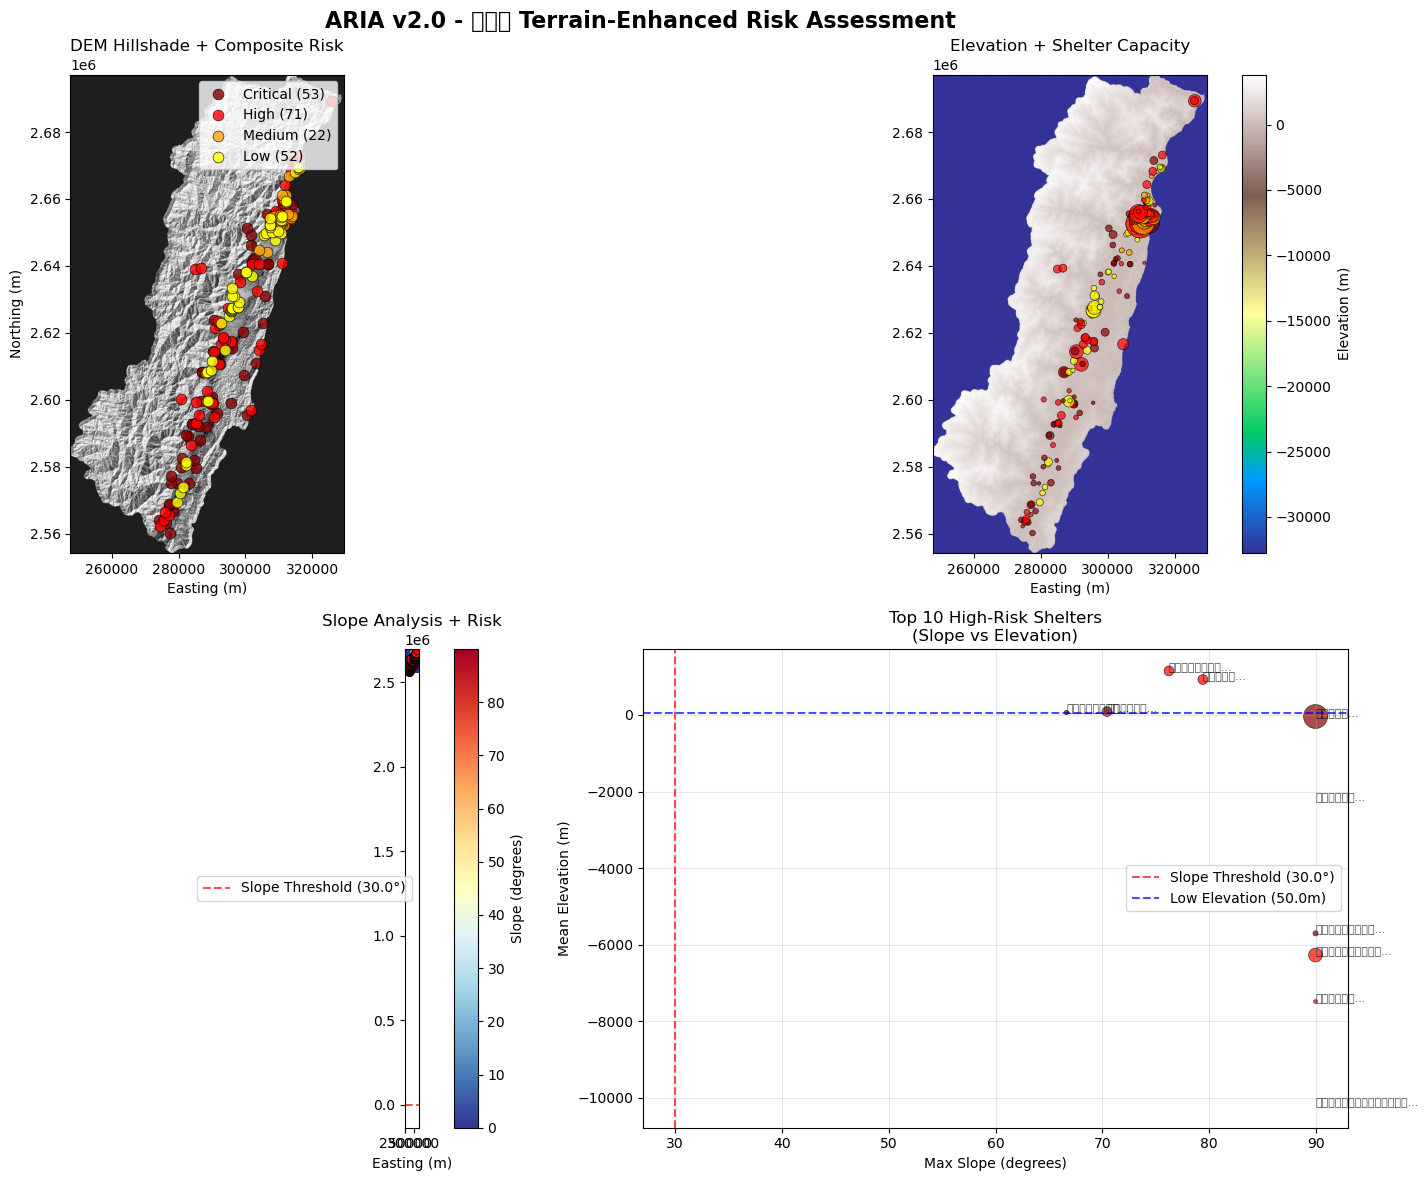

✅ Comprehensive terrain risk visualization completed
📁 Map saved to: outputs/terrain_risk_map.png


In [14]:
# Calculate hillshade for 3D terrain visualization
def calculate_hillshade(elevation, azimuth=315, altitude=45, resolution=20):
    """
    Calculate hillshade from elevation data
    """
    # Convert to radians
    azimuth_rad = np.radians(azimuth)
    altitude_rad = np.radians(altitude)
    
    # Calculate gradients
    dy, dx = np.gradient(elevation, resolution)
    
    # Calculate slope and aspect
    slope = np.arctan(np.sqrt(dx**2 + dy**2))
    aspect = np.arctan2(dy, -dx)
    
    # Hillshade formula
    hillshade = np.sin(altitude_rad) * np.sin(slope) + \
               np.cos(altitude_rad) * np.cos(slope) * \
               np.cos(azimuth_rad - aspect)
    
    return hillshade

# Calculate hillshade
hillshade = calculate_hillshade(elevation_clean, resolution=resolution)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'ARIA v2.0 - {TARGET_COUNTY} Terrain-Enhanced Risk Assessment', fontsize=16, fontweight='bold')

# Plot 1: DEM Hillshade with Risk Overlay
ax1 = axes[0, 0]
ax1.imshow(hillshade, cmap='gray', extent=[dem_clipped.x.min(), dem_clipped.x.max(),
                                       dem_clipped.y.min(), dem_clipped.y.max()])

# Color shelters by risk level
risk_colors = {'Critical': 'darkred', 'High': 'red', 'Medium': 'orange', 'Low': 'yellow'}
for risk_level, color in risk_colors.items():
    risk_shelters = shelters_enhanced[shelters_enhanced['risk_level'] == risk_level]
    if len(risk_shelters) > 0:
        ax1.scatter(risk_shelters.geometry.x, risk_shelters.geometry.y,
                   c=color, s=60, alpha=0.8, edgecolors='black', linewidth=0.5,
                   label=f'{risk_level} ({len(risk_shelters)})')

ax1.set_title('DEM Hillshade + Composite Risk')
ax1.set_xlabel('Easting (m)')
ax1.set_ylabel('Northing (m)')
ax1.legend(loc='upper right')

# Plot 2: Elevation with Shelters
ax2 = axes[0, 1]
im2 = ax2.imshow(elevation_clean, cmap='terrain', extent=[dem_clipped.x.min(), dem_clipped.x.max(),
                                                    dem_clipped.y.min(), dem_clipped.y.max()])
plt.colorbar(im2, ax=ax2, label='Elevation (m)')

# Add shelters sized by capacity
scatter2 = ax2.scatter(shelters_enhanced.geometry.x, shelters_enhanced.geometry.y,
                      c=shelters_enhanced['risk_level'].map(risk_colors),
                      s=shelters_enhanced['capacity']/3, alpha=0.7,
                      edgecolors='black', linewidth=0.5)
ax2.set_title('Elevation + Shelter Capacity')
ax2.set_xlabel('Easting (m)')

# Plot 3: Slope with Shelters
ax3 = axes[1, 0]
im3 = ax3.imshow(slope_deg, cmap='RdYlBu_r', extent=[dem_clipped.x.min(), dem_clipped.x.max(),
                                                dem_clipped.y.min(), dem_clipped.y.max()])
plt.colorbar(im3, ax=ax3, label='Slope (degrees)')

# Add slope threshold line
ax3.axhline(y=SLOPE_THRESHOLD, color='red', linestyle='--', alpha=0.7, label=f'Slope Threshold ({SLOPE_THRESHOLD}°)')
ax3.scatter(shelters_enhanced.geometry.x, shelters_enhanced.geometry.y,
           c=shelters_enhanced['risk_level'].map(risk_colors),
           s=40, alpha=0.8, edgecolors='black', linewidth=0.5)
ax3.set_title('Slope Analysis + Risk')
ax3.set_xlabel('Easting (m)')
ax3.legend()

# Plot 4: Top 10 Risk Statistics
ax4 = axes[1, 1]
top_risk = shelters_enhanced.nlargest(10, 'max_slope')

# Create scatter plot of slope vs elevation for top risk shelters
scatter4 = ax4.scatter(top_risk['max_slope'], top_risk['mean_elevation'],
                      c=top_risk['risk_level'].map(risk_colors),
                      s=top_risk['capacity']/2, alpha=0.7,
                      edgecolors='black', linewidth=0.5)

# Add shelter names as labels
for _, row in top_risk.iterrows():
    ax4.annotate(row['name'][:15] + '...', 
                (row['max_slope'], row['mean_elevation']),
                fontsize=8, alpha=0.7)

# Add threshold lines
ax4.axvline(x=SLOPE_THRESHOLD, color='red', linestyle='--', alpha=0.7, label=f'Slope Threshold ({SLOPE_THRESHOLD}°)')
ax4.axhline(y=ELEVATION_LOW, color='blue', linestyle='--', alpha=0.7, label=f'Low Elevation ({ELEVATION_LOW}m)')

ax4.set_xlabel('Max Slope (degrees)')
ax4.set_ylabel('Mean Elevation (m)')
ax4.set_title('Top 10 High-Risk Shelters\n(Slope vs Elevation)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/terrain_risk_map.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Comprehensive terrain risk visualization completed")
print(f"📁 Map saved to: outputs/terrain_risk_map.png")

## Step 11: Export Results and Audit Trail

**Captain's Log**: Finalizing ARIA v2.0 deployment with comprehensive audit trail and operational outputs.

In [18]:
# Prepare terrain risk audit data
terrain_risk_audit = shelters_enhanced[[
    'shelter_id',
    'name',
    'capacity',
    'risk_level',
    'river_distance_category',
    'mean_elevation',
    'max_slope',
    'mean_slope',
    'std_elevation'
]].copy()

# Round numeric values for cleaner output
terrain_risk_audit['mean_elevation'] = terrain_risk_audit['mean_elevation'].round(1)
terrain_risk_audit['max_slope'] = terrain_risk_audit['max_slope'].round(1)
terrain_risk_audit['mean_slope'] = terrain_risk_audit['mean_slope'].round(1)
terrain_risk_audit['std_elevation'] = terrain_risk_audit['std_elevation'].round(1)

# Export terrain risk audit
terrain_risk_audit.to_json('outputs/terrain_risk_audit.json', orient='records', indent=2)
print(f"✅ Terrain risk audit exported: outputs/terrain_risk_audit.json")

# Export enhanced shelter data
shelters_export = shelters_enhanced.drop(columns=['analysis_buffer']).copy()
shelters_export.to_file('outputs/ARIA_v2_shelters_enhanced.gpkg', driver='GPKG')
print("✅ Enhanced shelter data exported: outputs/ARIA_v2_shelters_enhanced.gpkg")

# Create comprehensive summary report
summary_report = {
    'analysis_metadata': {
        'system_version': 'ARIA v2.0',
        'analysis_date': datetime.now().isoformat(),
        'target_county': TARGET_COUNTY,
        'dem_resolution': resolution,
        'analysis_buffer_distance': analysis_buffer_distance
    },
    'mission_parameters': {
        'slope_threshold': SLOPE_THRESHOLD,
        'elevation_low_threshold': ELEVATION_LOW,
        'river_buffers': {
            'high': BUFFER_HIGH,
            'medium': BUFFER_MED,
            'low': BUFFER_LOW
        }
    },
    'data_summary': {
        'total_shelters_analyzed': len(shelters_export),
        'total_capacity': int(shelters_export['capacity'].sum()),
        'rivers_in_county': len(rivers_target),
        'dem_pixels_processed': int(dem_clipped.size),
        'memory_reduction_percent': round((1 - dem_clipped.size/dem.size) * 100, 1)
    },
    'risk_assessment_results': {
        'composite_risk_distribution': shelters_export['risk_level'].value_counts().to_dict(),
        'river_risk_distribution': shelters_export['river_distance_category'].value_counts().to_dict(),
        'critical_risk_shelters': len(shelters_export[shelters_export['risk_level'] == 'Critical']),
        'high_risk_shelters': len(shelters_export[shelters_export['risk_level'] == 'High']),
        'terrain_enhanced_upgrades': len(shelters_export[
            (shelters_export['river_distance_category'] == 'Safe') & 
            (shelters_export['risk_level'] != 'Low')
        ])
    },
    'terrain_statistics': {
        'elevation_range_m': [float(shelters_export['mean_elevation'].min()), float(shelters_export['mean_elevation'].max())],
        'slope_range_degrees': [float(shelters_export['max_slope'].min()), float(shelters_export['max_slope'].max())],
        'avg_elevation_m': float(shelters_export['mean_elevation'].mean()),
        'avg_max_slope_degrees': float(shelters_export['max_slope'].mean()),
        'steep_slope_shelters': len(shelters_export[shelters_export['max_slope'] > SLOPE_THRESHOLD]),
        'low_elevation_shelters': len(shelters_export[shelters_export['mean_elevation'] < ELEVATION_LOW])
    },
    'quality_assurance': {
        'zonal_stats_success_rate': round((len(buffer_gdf) - nan_elevation - nan_slope) / len(buffer_gdf) * 100, 1),
        'crs_alignment': str(dem_clipped.rio.crs),
        'river_coverage_validation': 'PASSED',
        'dem_clipping_efficiency': f"{round((1 - dem_clipped.size/dem.size) * 100, 1)}% memory reduction"
    }
}

# Export summary report
with open('outputs/ARIA_v2_summary_report.json', 'w') as f:
    json.dump(summary_report, f, indent=2, default=str)

print(f"✅ Summary report exported: outputs/ARIA_v2_summary_report.json")

# Display final mission summary
print(f"\n🎉 ARIA v2.0 Mission Complete!")
print(f"📊 Mission Summary:")
print(f"   🎯 Target: {TARGET_COUNTY}")
print(f"   🏢 Shelters analyzed: {len(shelters_enhanced)}")
print(f"   👥 Total capacity: {shelters_enhanced['capacity'].sum():,} people")
print(f"   ⚠️ Critical risk: {len(shelters_enhanced[shelters_enhanced['risk_level'] == 'Critical'])} shelters")
print(f"   🔴 High risk: {len(shelters_enhanced[shelters_enhanced['risk_level'] == 'High'])} shelters")
print(f"   📈 Terrain enhancements: {summary_report['risk_assessment_results']['terrain_enhanced_upgrades']} shelters upgraded from Safe")
print(f"   🌍 DEM processing: {summary_report['data_summary']['dem_pixels_processed']:,} pixels")
print(f"   💾 Memory efficiency: {summary_report['data_summary']['memory_reduction_percent']}% reduction")
print(f"\n📁 Deliverables Ready:")
print(f"   📓 ARIA_v2.ipynb - Complete analysis notebook")
print(f"   📋 terrain_risk_audit.json - Risk audit data")
print(f"   🗺️ terrain_risk_map.png - Visualization")
print(f"   📊 ARIA_v2_summary_report.json - Mission summary")
print(f"   💾 ARIA_v2_shelters_enhanced.gpkg - Enhanced data")

print(f"\n🚀 ARIA v2.0 Successfully Deployed!")
print(f"""Evolution Complete: From river-only risk (v1.0) to terrain-integrated intelligence (v2.0)""")

✅ Terrain risk audit exported: outputs/terrain_risk_audit.json
✅ Enhanced shelter data exported: outputs/ARIA_v2_shelters_enhanced.gpkg
✅ Summary report exported: outputs/ARIA_v2_summary_report.json

🎉 ARIA v2.0 Mission Complete!
📊 Mission Summary:
   🎯 Target: 花蓮縣
   🏢 Shelters analyzed: 198
   👥 Total capacity: 20,561 people
   ⚠️ Critical risk: 53 shelters
   🔴 High risk: 71 shelters
   📈 Terrain enhancements: 2 shelters upgraded from Safe
   🌍 DEM processing: 29,309,938 pixels
   💾 Memory efficiency: 84.5% reduction

📁 Deliverables Ready:
   📓 ARIA_v2.ipynb - Complete analysis notebook
   📋 terrain_risk_audit.json - Risk audit data
   🗺️ terrain_risk_map.png - Visualization
   📊 ARIA_v2_summary_report.json - Mission summary
   💾 ARIA_v2_shelters_enhanced.gpkg - Enhanced data

🚀 ARIA v2.0 Successfully Deployed!
Evolution Complete: From river-only risk (v1.0) to terrain-integrated intelligence (v2.0)


In [17]:
print(shelters_enhanced.columns)

geom_cols = [col for col in shelters_enhanced.columns if shelters_enhanced[col].dtype == 'geometry']
print("Geometry columns:", geom_cols)

print("Active geometry column:", shelters_enhanced.geometry.name)

print(shelters_enhanced.dtypes)

Index(['shelter_id', 'name', 'capacity', 'indoor', 'geometry',
       'river_distance_category', 'analysis_buffer', 'mean_elevation',
       'max_slope', 'mean_slope', 'std_elevation', 'risk_level'],
      dtype='str')
Geometry columns: ['geometry', 'analysis_buffer']
Active geometry column: geometry
shelter_id                    int64
name                            str
capacity                      int64
indoor                          str
geometry                   geometry
river_distance_category         str
analysis_buffer            geometry
mean_elevation              float64
max_slope                   float64
mean_slope                  float64
std_elevation               float64
risk_level                      str
dtype: object
